Description: This program predicts if a passenger will survive on the titanic.

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
titanic = pd.read_csv('../input/titanic/train.csv')

# Print the first 5 rows of the data
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Count the number of rows and columns in the data set
titanic.shape

(891, 12)

In [4]:
# Create a class column using pclass
titanic['Class'] = titanic['Pclass'].map({1:'First', 2:'Second', 3:'Third'})
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Class
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Third
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,First
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Third
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,First
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Third
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Second
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,First
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Third
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,First


In [5]:
# Get some statistics
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Get a count of the number of survivors
titanic['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

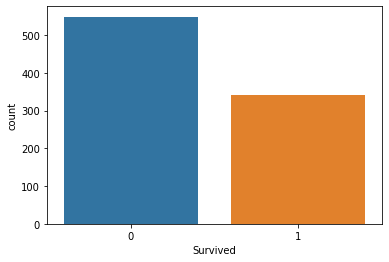

In [7]:
# Visualize the count of survivors
sns.countplot(x='Survived', data=titanic);

In [8]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Class'],
      dtype='object')

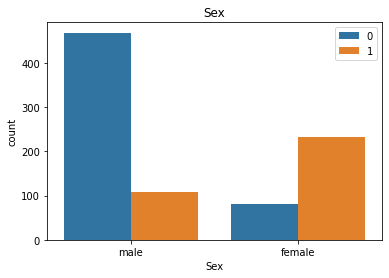

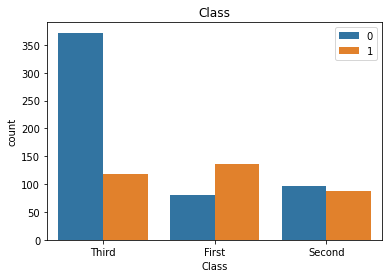

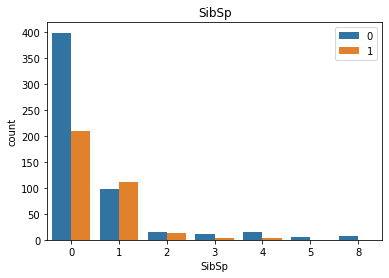

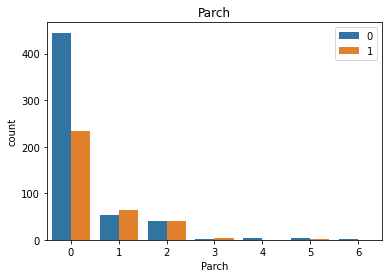

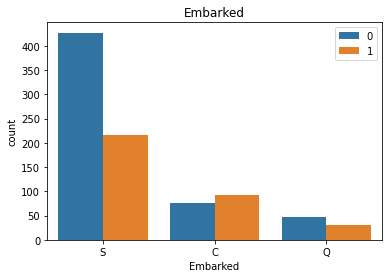

In [9]:
# Visualize the count of survivors for columns 'sex', 'pclass', 'sibsp', 'parch', 'embarked'

cols = ['Sex', 'Class', 'SibSp', 'Parch', 'Embarked']

for col in cols:
    sns.countplot(x=col, data=titanic, hue='Survived');
    plt.title(col)
    plt.legend(loc='upper right')
    plt.show()

In [10]:
# Look at survival rate by sex
titanic.groupby('Sex')[['Survived']].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [11]:
# Look at survival rate by sex and class
titanic.pivot_table('Survived', index='Sex', columns='Class')

Class,First,Second,Third
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


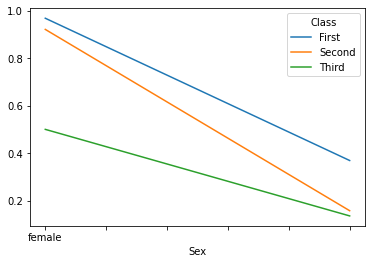

In [12]:
# Look at survival rate by sex and class visually
titanic.pivot_table('Survived', index='Sex', columns='Class').plot();

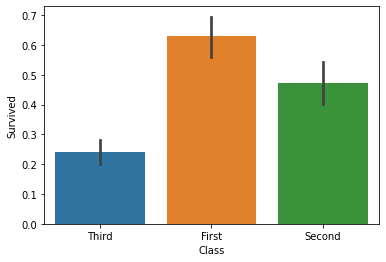

In [13]:
# Plot the survival rate of each class
sns.barplot(x='Class', y='Survived', data=titanic);

In [14]:
# Look at survival rate by sex, age and class
age = pd.cut(titanic['Age'], [0, 18, 80])
titanic.pivot_table('Survived', ['Sex', age], 'Class')

Class               First    Second     Third
Sex    Age                                   
female (0, 18]   0.909091  1.000000  0.511628
       (18, 80]  0.972973  0.900000  0.423729
male   (0, 18]   0.800000  0.600000  0.215686
       (18, 80]  0.375000  0.071429  0.133663

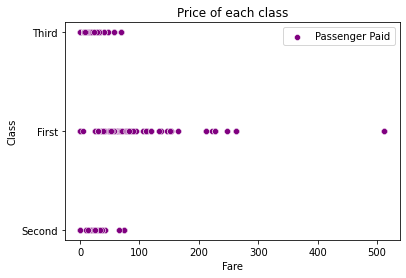

In [15]:
# Plot the prices paid of each class
sns.scatterplot(x='Fare', y='Class', data=titanic, color='purple', label='Passenger Paid');
plt.title('Price of each class');

In [16]:
# Count empty values in each column
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Class            0
dtype: int64

In [17]:
# Look at all values in each column and get a count

cols = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Class', 'Embarked']

for col in cols:
    print(titanic[col].value_counts())
    print()

0    549
1    342
Name: Survived, dtype: int64

3    491
1    216
2    184
Name: Pclass, dtype: int64

male      577
female    314
Name: Sex, dtype: int64

24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: Age, Length: 88, dtype: int64

0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64

0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: Parch, dtype: int64

Third     491
First     216
Second    184
Name: Class, dtype: int64

S    644
C    168
Q     77
Name: Embarked, dtype: int64



In [18]:
# Drop the columns
titanic.drop(['Cabin', 'Class', 'PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [19]:
# Remove rows with missing values
titanic.dropna(subset=['Embarked', 'Age'], inplace=True)

In [20]:
# Count the new number of rows and columns in the data set
titanic.shape

(712, 8)

In [21]:
# Look at the data types
titanic.dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

In [22]:
# Print unique values in the columns
print(titanic['Sex'].unique())
print(titanic['Embarked'].unique())

['male' 'female']
['S' 'C' 'Q']


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode the sex column
titanic.iloc[:, 2] = le.fit_transform(titanic.iloc[:, 2].values)

# Encode the embarked column
titanic.iloc[:, 7] = le.fit_transform(titanic.iloc[:, 7].values)

In [24]:
# Print unique values in the columns
print(titanic['Sex'].unique())
print(titanic['Embarked'].unique())

[1 0]
[2 0 1]


In [25]:
# Look at the data types
titanic.dtypes

Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object

In [26]:
# Split the data into independent 'X' and dependent 'Y' variables

X = titanic.iloc[:, 1:8].values
y = titanic.iloc[:, 0].values

In [27]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [28]:
# Scale the data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [29]:
# Create a function with many machine learning models
def models(X_train, y_train):
    
    # Use logistic regression
    from sklearn.linear_model import LogisticRegression
    log = LogisticRegression(random_state=0)
    log.fit(X_train, y_train)
    
    # Use KNeighbors
    from sklearn.neighbors import KNeighborsClassifier
    knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    knn.fit(X_train, y_train)
    
    # Use SVC (linear kernel)
    from sklearn.svm import SVC
    svc_lin = SVC(kernel='linear', random_state=0)
    svc_lin.fit(X_train, y_train)
    
    # Use SVC (RBF kernel)
    from sklearn.svm import SVC
    svc_rbf = SVC(kernel='rbf', random_state=0)
    svc_rbf.fit(X_train, y_train)
    
    # Use GaussianNB
    from sklearn.naive_bayes import GaussianNB
    gauss = GaussianNB()
    gauss.fit(X_train, y_train)
    
    # Use Decision tree
    from sklearn.tree import DecisionTreeClassifier
    tree = DecisionTreeClassifier(criterion='entropy', random_state=0)
    tree.fit(X_train, y_train)
    
    # Use RandomForestClassifier
    from sklearn.ensemble import RandomForestClassifier
    forest = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
    forest.fit(X_train, y_train)
    
    # Print the training accuracy for each model
    print('[0]Logistic Regression Training Accuracy: ', log.score(X_train, y_train))
    print('[1]K Neighbors Classifier Training Accuracy: ', knn.score(X_train, y_train))
    print('[2]SVC Linear Training Accuracy: ', svc_lin.score(X_train, y_train))
    print('[3]SVC RBF Training Accuracy: ', svc_rbf.score(X_train, y_train))
    print('[4]Gaussian NB Training Accuracy: ', gauss.score(X_train, y_train))
    print('[5]Decision Tree Training Accuracy: ', tree.score(X_train, y_train))
    print('[6]Random Forest Training Accuracy: ', forest.score(X_train, y_train))
    
    
    return log, knn, svc_lin, svc_rbf, gauss, tree, forest  
    

In [30]:
# Get and train all of the models
model = models(X_train, y_train)

[0]Logistic Regression Training Accuracy:  0.7978910369068541
[1]K Neighbors Classifier Training Accuracy:  0.8664323374340949
[2]SVC Linear Training Accuracy:  0.7768014059753954
[3]SVC RBF Training Accuracy:  0.8506151142355008
[4]Gaussian NB Training Accuracy:  0.8031634446397188
[5]Decision Tree Training Accuracy:  0.9929701230228472
[6]Random Forest Training Accuracy:  0.9753954305799648


In [31]:
# Show the confusion matrix and accuracy for all of the models on the test data

from sklearn.metrics import confusion_matrix

for i in range(len(model)):
    cm = confusion_matrix(y_test, model[i].predict(X_test))
    
    # Extract TN, FP, FN, TP
    TN, FP, FN, TP = cm.ravel()
    
    test_score = (TP + TN) / (TP + TN + FN + FP)
    
    print(cm)
    print('Model[{}] Testing Accuracy = "{}"'.format(i, test_score))

[[75  7]
 [19 42]]
Model[0] Testing Accuracy = "0.8181818181818182"
[[67 15]
 [20 41]]
Model[1] Testing Accuracy = "0.7552447552447552"
[[70 12]
 [18 43]]
Model[2] Testing Accuracy = "0.7902097902097902"
[[75  7]
 [22 39]]
Model[3] Testing Accuracy = "0.7972027972027972"
[[69 13]
 [27 34]]
Model[4] Testing Accuracy = "0.7202797202797203"
[[54 28]
 [12 49]]
Model[5] Testing Accuracy = "0.7202797202797203"
[[73  9]
 [14 47]]
Model[6] Testing Accuracy = "0.8391608391608392"


In [32]:
# Get feature importance
forest = model[6]
importances = pd.DataFrame({'feature':titanic.iloc[:, 1:8].columns,
                           'importance': np.round(forest.feature_importances_, 3)})
importances = importances.sort_values('importance', ascending=False).set_index('feature')
importances

,importance
feature,
Age,0.300
Fare,0.296
Sex,0.183
Pclass,0.098
SibSp,0.050
Parch,0.044
Embarked,0.030


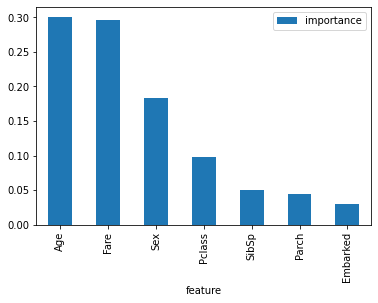

In [33]:
# Visualize the importances 
importances.plot.bar();

In [34]:
test = pd.read_csv('../input/titanic/test.csv')
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [35]:
test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [36]:
# Drop the columns
test.drop(['Cabin', 'Name', 'Ticket'], axis=1, inplace=True)

In [37]:
# Dropping null value rows
test.dropna(inplace=True)

In [38]:
test.isna().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

In [39]:
# Creating a list of passenger id's
passenger_id = test.loc[:, 'PassengerId']
passenger_id

0       892
1       893
2       894
3       895
4       896
       ... 
409    1301
411    1303
412    1304
414    1306
415    1307
Name: PassengerId, Length: 331, dtype: int64

In [40]:
# Drop the columns
test.drop(['PassengerId'], axis=1, inplace=True)

In [41]:
# Encode the sex column
test.loc[:, 'Sex'] = le.fit_transform(test.loc[:, 'Sex'].values)

# Encode the embarked column
test.loc[:, 'Embarked'] = le.fit_transform(test.loc[:, 'Embarked'].values)

In [42]:
# Scaling the test data
test_scaled = sc.fit_transform(test)

In [43]:
# Making predictions on test data
predictions = model[6].predict(test_scaled)

In [44]:
# Making dataframe containing passenger id and survived column
submission = pd.DataFrame({'PassengerId': passenger_id, 'Survived': predictions})
submission.to_csv('submission.csv', index=False)